# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("movie_ratings_analysis_650_movies.csv")

# Initial Data Inspection

-- First 5 Rows

In [4]:
df.head()

,Movie_ID,Title,Genre,Release_Year,Director,Runtime_Minutes,Rating,Votes,Revenue_Million,Language,Country,Budget_Million
0,M0642,Burning Future,Animation,2000,David Miller,80,7.3,72461,74.52,Hindi,India,21.22
1,M0225,City Empire,Animation,2000,Hans Weber,103,7.8,33423,201.72,English,Canada,70.55
2,M0447,City Horizon,Comedy,2000,David Miller,105,7.2,354697,75.77,English,USA,41.85
3,M0175,City War,Romance,2000,James Carter,95,6.1,165315,122.68,Hindi,India,22.01
4,M0560,Crimson Moon,Action,2000,Vikram Kapoor,149,6.9,21023,22.49,Hindi,India,6.90


-- Last 5 Rows

In [6]:
df.tail()

,Movie_ID,Title,Genre,Release_Year,Director,Runtime_Minutes,Rating,Votes,Revenue_Million,Language,Country,Budget_Million
645,M0022,Summer Escape,Animation,2025,Pierre Laurent,91,7.7,143731,9.19,English,USA,3.63
646,M0379,Summer Signal,Romance,2025,James Carter,92,7.5,275214,58.86,English,USA,38.73
647,M0417,Wild Destiny,Adventure,2025,Sofia Bennett,126,6.4,109683,67.51,English,Canada,101.06
648,M0090,Wild Kingdom,Sci-Fi,2025,Yuna Kim,113,7.3,27014,21.48,English,UK,18.49
649,M0513,Winter Legacy,Action,2025,Vikram Kapoor,137,7.5,395636,34.31,English,Australia,13.81


-- Shape

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 650
Columns: 12


-- Column Names

In [10]:
print(df.columns.tolist())

['Movie_ID', 'Title', 'Genre', 'Release_Year', 'Director', 'Runtime_Minutes', 'Rating', 'Votes', 'Revenue_Million', 'Language', 'Country', 'Budget_Million']


-- Dataset Info

df.info()

-- CHeck Missing / NULL Values

In [14]:
df.isnull().sum()

Movie_ID           0
Title              0
Genre              0
Release_Year       0
Director           0
Runtime_Minutes    0
Rating             0
Votes              0
Revenue_Million    0
Language           0
Country            0
Budget_Million     0
dtype: int64

-- Checking Duplicates

In [16]:
df.duplicated().sum()

np.int64(0)

-- Checking Data TYpes

In [18]:
df.dtypes

Movie_ID               str
Title                  str
Genre                  str
Release_Year         int64
Director               str
Runtime_Minutes      int64
Rating             float64
Votes                int64
Revenue_Million    float64
Language               str
Country                str
Budget_Million     float64
dtype: object

-- Discriptive Statistics

In [20]:
df.describe()

,Release_Year,Runtime_Minutes,Rating,Votes,Revenue_Million,Budget_Million
count,650.000000,650.000000,650.000000,6.500000e+02,650.000000,650.000000
mean,2012.200000,118.161538,7.037385,1.164850e+05,81.265077,31.388138
std,7.560338,20.507432,0.727854,1.503892e+05,103.157292,28.442541
min,2000.000000,75.000000,4.800000,8.000000e+03,2.550000,2.380000
25%,2005.000000,103.250000,6.500000,3.347500e+04,25.752500,14.372500
50%,2012.000000,119.000000,7.100000,6.602300e+04,52.130000,23.430000
75%,2019.000000,133.000000,7.500000,1.456008e+05,97.355000,38.915000
max,2025.000000,171.000000,9.000000,1.591980e+06,1103.450000,237.340000


-- Basic Analysis

In [22]:
# Genre distribution
genre_counts = df["Genre"].value_counts()

print("\n--- MOVIES BY GENRE ---")
print(genre_counts)


--- MOVIES BY GENRE ---
Genre
Action       98
Drama        79
Comedy       72
Romance      58
Sci-Fi       52
Horror       52
Animation    51
Thriller     50
Crime        46
Adventure    45
Mystery      29
Fantasy      18
Name: count, dtype: int64


In [23]:
# Average rating by genre
avg_rating_genre = (
    df.groupby("Genre")["Rating"]
      .mean()
      .sort_values(ascending=False)
)

print("\n--- AVERAGE RATING BY GENRE ---")
print(avg_rating_genre.round(2))


--- AVERAGE RATING BY GENRE ---
Genre
Drama        7.61
Mystery      7.40
Animation    7.30
Sci-Fi       7.18
Crime        7.18
Fantasy      7.07
Adventure    7.02
Thriller     6.99
Action       6.88
Romance      6.84
Comedy       6.74
Horror       6.42
Name: Rating, dtype: float64


In [24]:
# Movies released by year
year_counts = df["Release_Year"].value_counts().sort_index()

print("\n--- MOVIES RELEASED BY YEAR ---")
print(year_counts)


--- MOVIES RELEASED BY YEAR ---
Release_Year
2000    26
2001    29
2002    29
2003    30
2004    25
2005    26
2006    20
2007    23
2008    23
2009    28
2010    19
2011    33
2012    24
2013    27
2014    28
2015    22
2016    20
2017    28
2018    19
2019    23
2020    25
2021    27
2022    29
2023    19
2024    25
2025    23
Name: count, dtype: int64


In [25]:
# Average rating by year
avg_rating_year = (
    df.groupby("Release_Year")["Rating"]
      .mean()
      .sort_index()
)

print("\n--- AVERAGE RATING BY YEAR ---")
print(avg_rating_year.round(2))



--- AVERAGE RATING BY YEAR ---
Release_Year
2000    7.06
2001    6.81
2002    7.13
2003    7.12
2004    7.13
2005    7.14
2006    6.72
2007    7.13
2008    7.17
2009    7.17
2010    6.85
2011    6.96
2012    6.95
2013    7.04
2014    6.75
2015    7.19
2016    6.88
2017    7.03
2018    7.26
2019    7.08
2020    7.24
2021    6.84
2022    7.28
2023    6.74
2024    7.12
2025    7.07
Name: Rating, dtype: float64


In [26]:

# Top 10 movies by votes
top_10_votes = (
    df.nlargest(10, "Votes")[["Title", "Votes", "Rating"]]
      .sort_values("Votes")
)

print("\n--- TOP 10 MOVIES BY VOTES ---")
print(top_10_votes)


--- TOP 10 MOVIES BY VOTES ---
               Title    Votes  Rating
214     Fallen Truth   622787     7.7
426       Rising War   647022     6.3
454    Secret Future   721483     8.2
606      City Signal   749180     7.2
525       Wild Night   787875     7.5
516       Lost World   791411     6.1
607  Crimson Journey   817228     7.4
386    Silver Hearts   903569     7.2
560  Forgotten World  1581570     7.2
212      Dark Empire  1591980     7.6


In [27]:
# Top 10 countries
country_counts = df["Country"].value_counts().head(10).sort_values()

print("\n--- TOP 10 COUNTRIES BY MOVIE COUNT ---")
print(country_counts)



--- TOP 10 COUNTRIES BY MOVIE COUNT ---
Country
Germany         22
Japan           23
France          41
South Korea     49
Australia       81
UK              98
India          101
Canada         114
USA            121
Name: count, dtype: int64


In [28]:

# Correlation
rating_votes_correlation = df["Rating"].corr(df["Votes"])
budget_revenue_correlation = df["Budget_Million"].corr(df["Revenue_Million"])

print("\n--- CORRELATION ---")
print("Rating vs Votes:", round(rating_votes_correlation, 3))
print("Budget vs Revenue:", round(budget_revenue_correlation, 3))


--- CORRELATION ---
Rating vs Votes: 0.073
Budget vs Revenue: 0.696


# Visualization

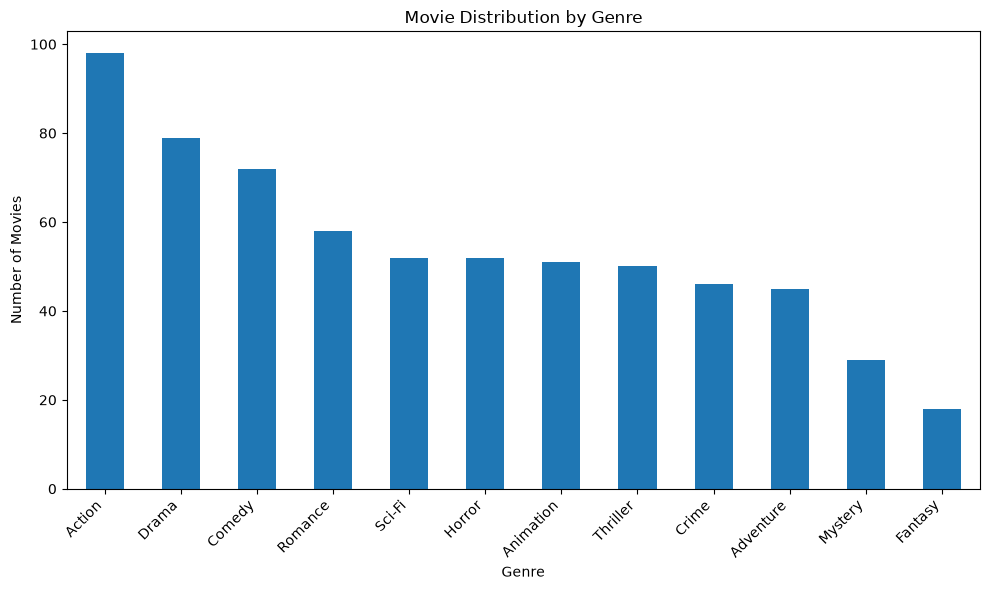

In [29]:
# CHART 1: MOVIE DISTRIBUTION BY GENRE

plt.figure(figsize=(10, 6))
genre_counts.plot(kind="bar")
plt.title("Movie Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


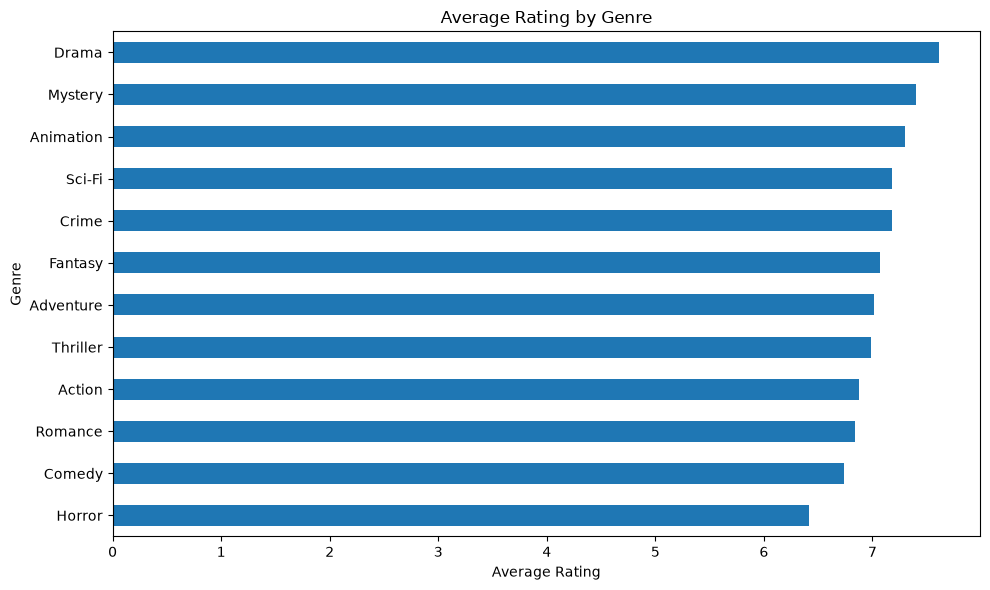

In [30]:
# CHART 2: AVERAGE RATING BY GENRE

plt.figure(figsize=(10, 6))
avg_rating_genre.sort_values().plot(kind="barh")
plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


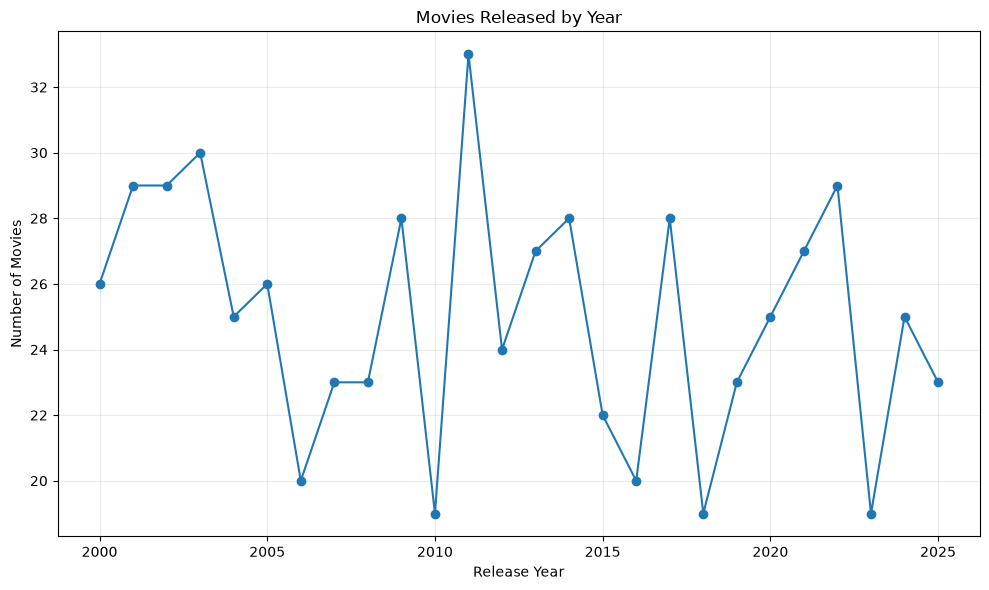

In [31]:
# CHART 3: MOVIES RELEASED BY YEAR

plt.figure(figsize=(10, 6))
year_counts.plot(kind="line", marker="o")
plt.title("Movies Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

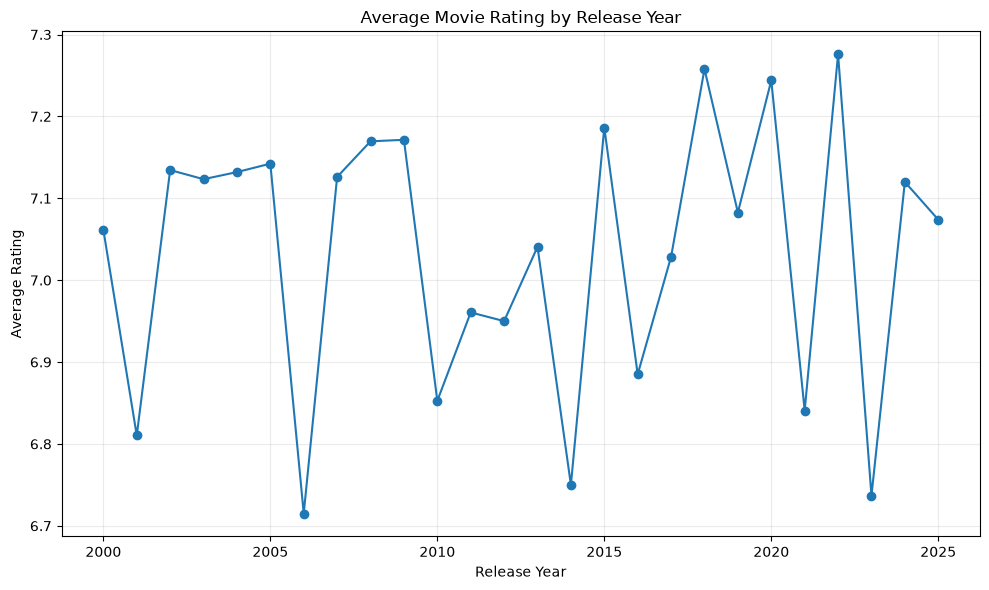

In [32]:
# CHART 4: AVERAGE RATING BY RELEASE YEAR

plt.figure(figsize=(10, 6))
avg_rating_year.plot(kind="line", marker="o")
plt.title("Average Movie Rating by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Rating")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

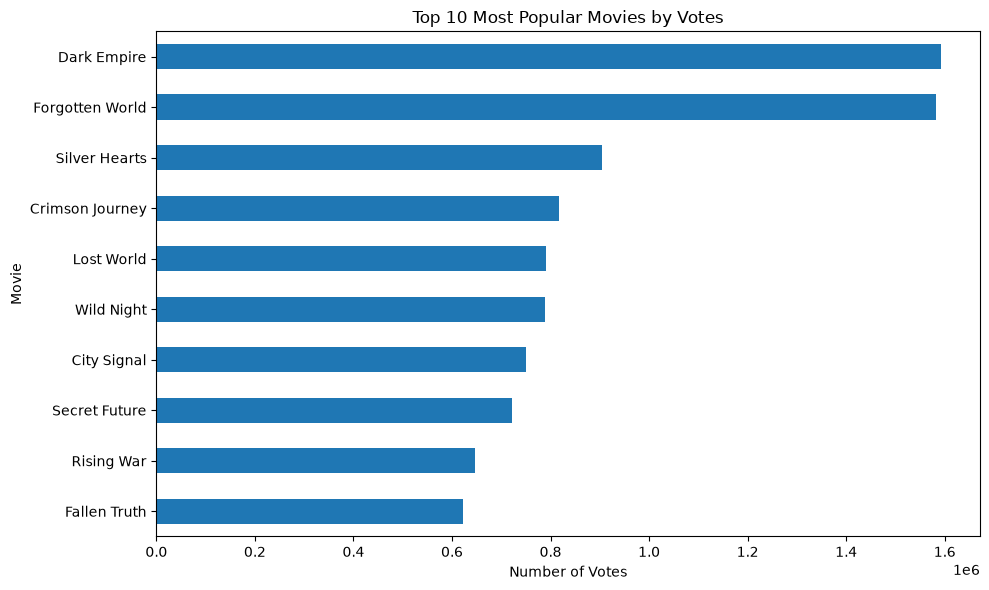

In [33]:
# CHART 5: TOP 10 MOST POPULAR MOVIES BY VOTES

plt.figure(figsize=(10, 6))
top_10_votes["Votes"].plot(kind="barh")
plt.yticks(range(len(top_10_votes)), top_10_votes["Title"])
plt.title("Top 10 Most Popular Movies by Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()


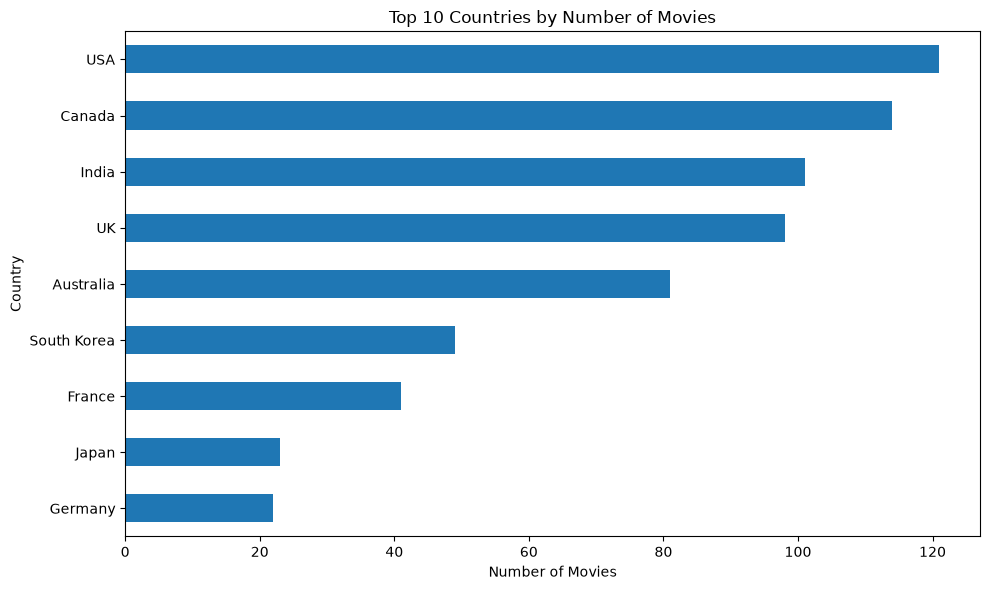

In [34]:
# CHART 6: TOP 10 COUNTRIES BY MOVIE COUNT

plt.figure(figsize=(10, 6))
country_counts.plot(kind="barh")
plt.title("Top 10 Countries by Number of Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


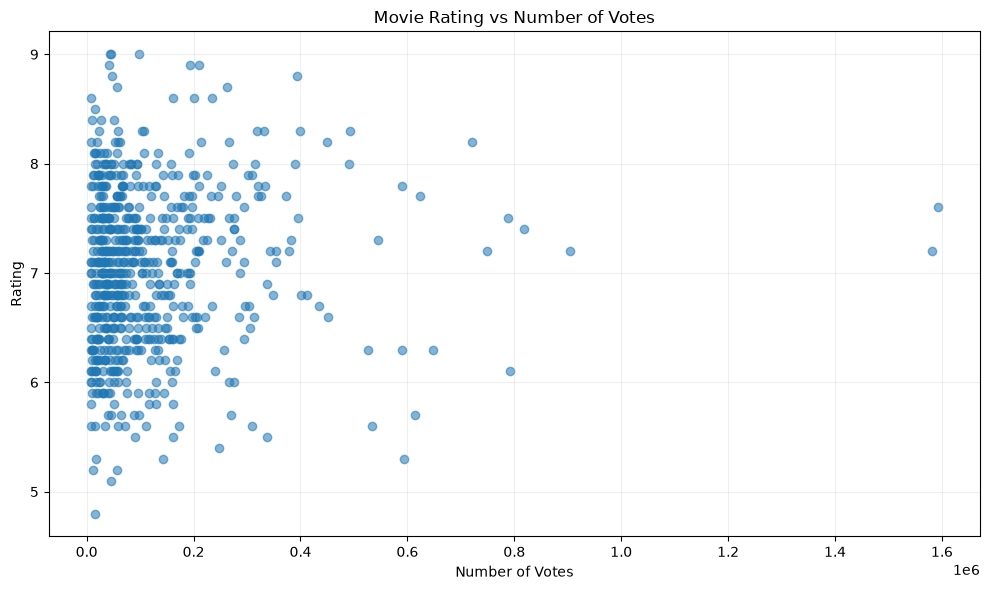

In [35]:
# CHART 7: RATING VS NUMBER OF VOTES

plt.figure(figsize=(10, 6))
plt.scatter(df["Votes"], df["Rating"], alpha=0.55)
plt.title("Movie Rating vs Number of Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Rating")
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()


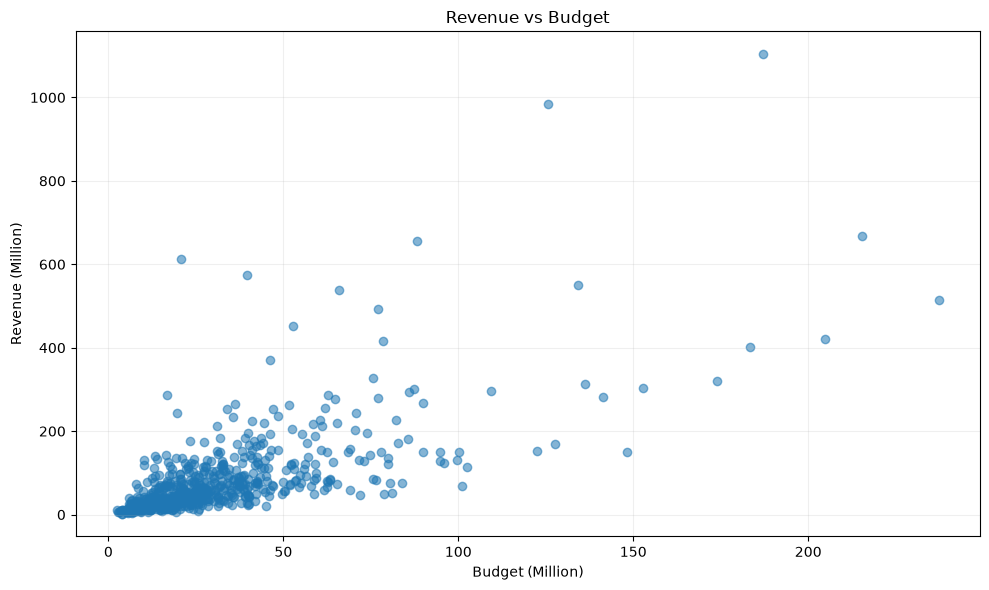

In [36]:
# CHART 8: REVENUE VS BUDGET

plt.figure(figsize=(10, 6))
plt.scatter(df["Budget_Million"], df["Revenue_Million"], alpha=0.55)
plt.title("Revenue vs Budget")
plt.xlabel("Budget (Million)")
plt.ylabel("Revenue (Million)")
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()


-- Rating Band Including...

In [37]:
 #Rating bands
def rating_band(rating):
    if rating >= 8:
        return "8.0+"
    elif rating >= 7:
        return "7.0-7.9"
    elif rating >= 6:
        return "6.0-6.9"
    else:
        return "<6.0"

df["Rating_Band"] = df["Rating"].apply(rating_band)

rating_band_counts = (
    df["Rating_Band"]
      .value_counts()
      .reindex(["8.0+", "7.0-7.9", "6.0-6.9", "<6.0"], fill_value=0)
)

print("\n--- RATING BAND DISTRIBUTION ---")
print(rating_band_counts)


--- RATING BAND DISTRIBUTION ---
Rating_Band
8.0+        66
7.0-7.9    302
6.0-6.9    237
<6.0        45
Name: count, dtype: int64


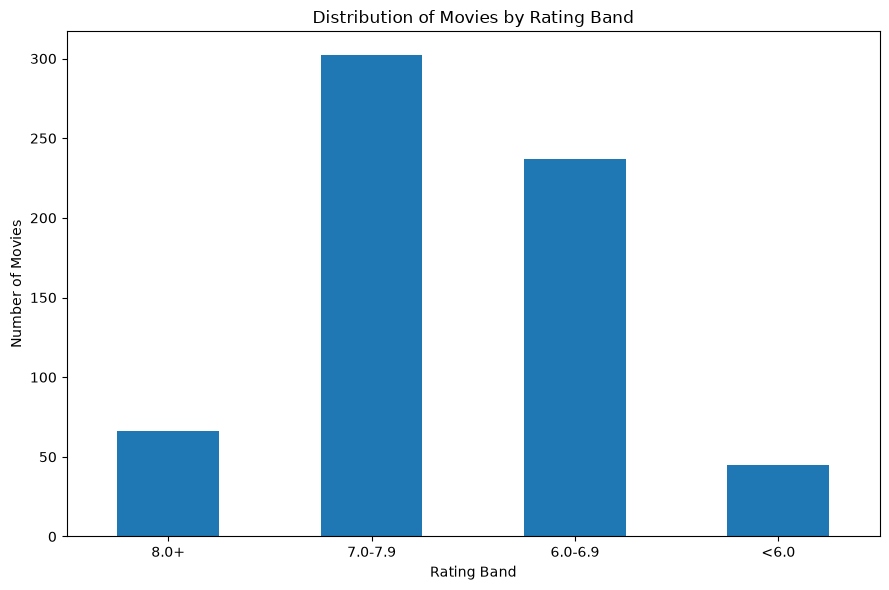

In [38]:
# CHART 9: RATING BAND DISTRIBUTION

plt.figure(figsize=(9, 6))
rating_band_counts.plot(kind="bar")
plt.title("Distribution of Movies by Rating Band")
plt.xlabel("Rating Band")
plt.ylabel("Number of Movies")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [39]:
print("\n" + "=" * 60)
print("MOVIE RATINGS ANALYSIS COMPLETED")
print("=" * 60)



MOVIE RATINGS ANALYSIS COMPLETED
